In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import pairwise_distances
import seaborn as sns
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import SelectKBest, f_classif

In [ ]:
# task 1

data = np.load('pzz_gene_data.npz')
print(list(data.keys()))

['X', 'y', 'informative_features', 'shuffle_idx']


In [ ]:
# 1 (a)

# Load & Split (50% test to highlight overfitting with small N)
X, y = data['X'], data['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Train Benchmark
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
elapsed = time.time() - start

# Results
print(f"Train Acc: {rf.score(X_train, y_train):.2f}")
print(f"Test Acc:  {rf.score(X_test, y_test):.2f}")
print(f"Time: {elapsed:.2f}s")
print(f"Non-zero importance features: {sum(rf.feature_importances_ > 0)}")


# 100 samples vs 5000 features...

Train Acc: 1.00
Test Acc:  0.65
Time: 0.34s
Non-zero importance features: 807


In [ ]:
# 1 (b)

print("--- Filter Method (ANOVA) ---")
results = {}

for k in [50, 100, 200]:
    # 1. Select features (Learn on Train ONLY)
    selector = SelectKBest(f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)

    # 2. Train on reduced set
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_sel, y_train)

    acc = rf.score(X_test_sel, y_test)
    results[k] = acc
    print(f"k={k}: Test Acc {acc:.2f}")

--- Filter Method (ANOVA) ---
k=50: Test Acc 0.82
k=100: Test Acc 0.77
k=200: Test Acc 0.79


In [ ]:
# 1 (c)

k = 50  # Target number of features (highest accuracy)

# 1. RFE (Recursive Feature Elimination) - Wrapper
# step=0.1 removes 10% features per iteration (speeds up)
rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=k, step=0.1)
rfe.fit(X_train, y_train)
idx_rfe = set(np.where(rfe.support_)[0])

# 2. Lasso / L1 (Embedded)
# Using LogisticRegression with L1 penalty to mimic Lasso for classification
l1_mod = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42).fit(X_train, y_train)
# Get indices of top k coefficients
idx_l1 = set(np.argsort(np.abs(l1_mod.coef_[0]))[-k:])

# 3. Random Forest Importance (Embedded)
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train).feature_importances_
idx_rf = set(np.argsort(rf_imp)[-k:])

# Check Overlap
print(f"RFE vs Lasso overlap: {len(idx_rfe & idx_l1)}")
print(f"RFE vs RF overlap:    {len(idx_rfe & idx_rf)}")
print(f"Lasso vs RF overlap:  {len(idx_l1 & idx_rf)}")
print(f"Common to all 3:      {len(idx_rfe & idx_l1 & idx_rf)}")

RFE vs Lasso overlap: 7
RFE vs RF overlap:    6
Lasso vs RF overlap:  7
Common to all 3:      4


--- Accuracy vs Dimension (n=200) ---
Dims: 20    -> Test Acc: 0.72
Dims: 100   -> Test Acc: 0.58
Dims: 500   -> Test Acc: 0.62
Dims: 1000  -> Test Acc: 0.51
Dims: 5000  -> Test Acc: 0.48


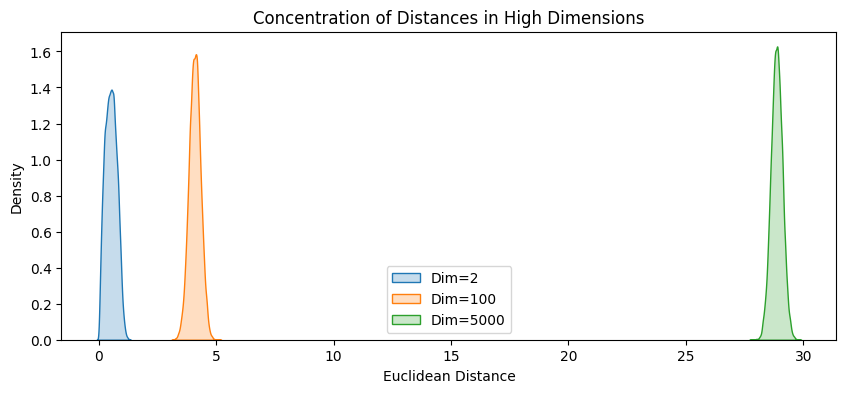

In [12]:
# 1 (d)

dims = [20, 100, 500, 1000, 5000]
acc_scores = []

# 1. Accuracy vs Dimension
print("--- Accuracy vs Dimension (n=200) ---")
for d in dims:
    # Generate fresh data with fixed useful signal but increasing noise features
    X_sim, y_sim = make_classification(n_samples=200, n_features=d, n_informative=20, n_redundant=0, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X_sim, y_sim, test_size=0.5, random_state=42)

    rf = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_tr, y_tr)
    acc = rf.score(X_te, y_te)
    acc_scores.append(acc)
    print(f"Dims: {d: <5} -> Test Acc: {acc:.2f}")

# 2. Euclidean Distance Distribution
plt.figure(figsize=(10, 4))
for d in [2, 100, 5000]:
    # Random uniform data
    X_rand = np.random.random((200, d))
    # Compute distances between all pairs
    dists = pairwise_distances(X_rand).flatten()
    # Keep only off-diagonal (non-zero)
    dists = dists[dists > 0]

    sns.kdeplot(dists, label=f'Dim={d}', fill=True)

plt.title("Concentration of Distances in High Dimensions")
plt.xlabel("Euclidean Distance")
plt.legend()
plt.show()

In [14]:
# task 2

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Encode Target: Yes->1, No->0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
# 2 (a)

# Logic: If Churn==1 (Customer left), days_since_last_call is 0 (we called them on exit).
#        If Churn==0 (Customer stayed), random 1-30 days.
# This leaks the FUTURE (Churn status) into the PAST (feature value).
df['days_since_last_call'] = np.where(
    df['Churn'] == 1,
    0,
    np.random.randint(1, 30, len(df))
)

# We train Model on the Leak + minimal features
# We select a few real features + our leaked one to show dominance
features = ['days_since_last_call', 'tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

print(f"--- LEAKAGE SIMULATION ---")
print(f"Test Accuracy: {model.score(X_test, y_test):.4f}")

print("\n--- FEATURE IMPORTANCE ---")
imps = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(imps)

--- LEAKAGE SIMULATION ---
Test Accuracy: 1.0000

--- FEATURE IMPORTANCE ---
days_since_last_call    0.907317
tenure                  0.060253
MonthlyCharges          0.025429
TotalCharges            0.007001
dtype: float64


In [ ]:
"""

Test Accuracy: 1.0000 → Suspicious/Wrong because human behavior (churn) is never 100% predictable; this perfect score proves the model is "cheating" by seeing the answer.

days_since_last_call: 0.90 → Target Leakage; this feature dominates the model because it contains information from the future (it was created using the target label), which won't be available in a real production environment

"""

In [ ]:
# 2 (b)

features_to_check = ['days_since_last_call', 'tenure', 'MonthlyCharges', 'TotalCharges']
suspicious_features = []

for col in features_to_check:
    corr = np.abs(df[col].corr(df['Churn']))
    clf_single = RandomForestClassifier(n_estimators=5, max_depth=3, random_state=42)
    clf_single.fit(X_train[[col]], y_train)
    acc = clf_single.score(X_test[[col]], y_test)

    print(f"Feature: {col: <22} | Correlation: {corr:.2f} | Single-Feat Acc: {acc:.2f}")

    if corr > 0.9 or acc > 0.9:
        suspicious_features.append(col)

print("-" * 60)
print(f"[ALARM] CANDIDATES FOR LEAKAGE: {suspicious_features}")

Feature: days_since_last_call   | Correlation: 0.68 | Single-Feat Acc: 1.00
Feature: tenure                 | Correlation: 0.35 | Single-Feat Acc: 0.75
Feature: MonthlyCharges         | Correlation: 0.19 | Single-Feat Acc: 0.73
Feature: TotalCharges           | Correlation: 0.20 | Single-Feat Acc: 0.75
------------------------------------------------------------
[ALARM] CANDIDATES FOR LEAKAGE: ['days_since_last_call']


In [ ]:
# 2 (c)

X_clean = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

# --- 1. BAD APPROACH (Leakage) ---
# We scale the WHOLE dataset before splitting.
# The model sees the distribution (mean/std) of the Test set.
scaler = StandardScaler()
X_bad_scaled = scaler.fit_transform(X_clean)
X_tr_bad, X_te_bad, y_tr, y_te = train_test_split(X_bad_scaled, y, test_size=0.3, random_state=42)

model_bad = LogisticRegression()
model_bad.fit(X_tr_bad, y_tr)
score_bad = model_bad.score(X_te_bad, y_te)

# --- 2. GOOD APPROACH (Pipeline) ---
# We split FIRST. Scaling happens independently inside the fold.
X_tr_good, X_te_good, y_tr_good, y_te_good = train_test_split(X_clean, y, test_size=0.3, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])
pipe.fit(X_tr_good, y_tr_good)
score_good = pipe.score(X_te_good, y_te_good)

print(f"Bad Approach Acc:  {score_bad:.4f} -> BIASED")
print(f"Good Approach Acc: {score_good:.4f} -> ROBUST")

Bad Approach Acc:  0.7889 -> BIASED
Good Approach Acc: 0.7889 -> ROBUST


In [21]:
checklist = """
### CHECKLIST ###

1. Czy cecha jest dostępna w momencie predykcji?
   - DOBRZE: Tak, dane istnieją w systemie przed wystąpieniem zdarzenia.
   - ŹLE: Nie, cecha powstaje po fakcie (np. "data rezygnacji" lub "kwota zwrotu").

2. Czy preprocessing jest wewnątrz Pipeline?
   - DOBRZE: Tak, statystyki (mean/std) liczone są tylko na zbiorze treningowym.
   - ŹLE: Nie, wykonano fit_transform na całych danych przed podziałem (wyciek statystyk).

3. Czy którakolwiek cecha ma korelację z targetem > 0.9?
   - DOBRZE: Nie, korelacje są naturalne i umiarkowane.
   - ŹLE: Tak, podejrzanie wysoka korelacja sugeruje, że cecha to "przefarbowany target".

4. Czy model wytrenowany na jednej cesze osiąga Accuracy > 90%?
   - DOBRZE: Nie, model musi łączyć wiele sygnałów, by działać skutecznie.
   - ŹLE: Tak, jedna cecha dominuje i zdradza wynik (Target Leakage).

5. Czy usunięto identyfikatory (ID) i numery wierszy?
   - DOBRZE: Tak, model uczy się generalnych wzorców.
   - ŹLE: Nie, model "wkuwa na pamięć" (overfitting) konkretnych klientów po ich ID.
"""

print(checklist)


### CHECKLIST ###

1. Czy cecha jest dostępna w momencie predykcji?
   - DOBRZE: Tak, dane istnieją w systemie przed wystąpieniem zdarzenia.
   - ŹLE: Nie, cecha powstaje po fakcie (np. "data rezygnacji" lub "kwota zwrotu").

2. Czy preprocessing jest wewnątrz Pipeline?
   - DOBRZE: Tak, statystyki (mean/std) liczone są tylko na zbiorze treningowym.
   - ŹLE: Nie, wykonano fit_transform na całych danych przed podziałem (wyciek statystyk).

3. Czy którakolwiek cecha ma korelację z targetem > 0.9?
   - DOBRZE: Nie, korelacje są naturalne i umiarkowane.
   - ŹLE: Tak, podejrzanie wysoka korelacja sugeruje, że cecha to "przefarbowany target".

4. Czy model wytrenowany na jednej cesze osiąga Accuracy > 90%?
   - DOBRZE: Nie, model musi łączyć wiele sygnałów, by działać skutecznie.
   - ŹLE: Tak, jedna cecha dominuje i zdradza wynik (Target Leakage).

5. Czy usunięto identyfikatory (ID) i numery wierszy?
   - DOBRZE: Tak, model uczy się generalnych wzorców.
   - ŹLE: Nie, model "wkuwa na pa